# Phần 1: Bài toán Hồi quy
**Dataset:** California Housing Prices (Kaggle / StatLib)  

---

## Mục lục
- [B. EDA & Tiền xử lý Dữ liệu](#b)
  - [B.1 Load & Mô tả dataset](#b1)
  - [B.2 Xử lý Missing Values](#b2)
  - [B.3 Phân bố biến mục tiêu](#b3)
  - [B.4 Ma trận tương quan & Scatter plots](#b4)
  - [B.5 Phát hiện Outliers](#b5)
  - [B.6 Feature Engineering & Encode Categorical](#b6)
  - [B.7 Stratified Train/Val/Test Split](#b7)
  - [B.8 Chuẩn hóa (StandardScaler)](#b8)
  - [B.9 Kiểm tra phân phối sau split](#b9)
- [C. Xây dựng và huấn luyện mô hình](#c)
  - [C.1 Linear Regression](#c1)
  - [C.2 Ridge/Lasso Regression](#c2)
  - [C.3 Mô hình với Hàm Cơ sở Phi Tuyến và Ablation Study](#c3)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

# Import toàn bộ helper functions từ utils.py
%load_ext autoreload
%autoreload 2
from utils import *

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = '../../data/housing.csv' 
print('Import thành công!')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Import thành công!


---
<a id='b'></a>
## B. Phân tích Khám phá & Tiền xử lý Dữ liệu

Phần này thực hiện đầy đủ pipeline EDA trước khi huấn luyện mô hình, bao gồm:
phân tích thống kê mô tả, phát hiện và xử lý missing values, phát hiện outliers,
phân tích tương quan, feature engineering, và chia dữ liệu train/val/test.

<a id='b1'></a>
### B.1 Load & Mô tả Dataset

**Dataset:** California Housing Prices, thu thập từ Census 1990 của California.  
Mỗi mẫu đại diện cho một **block group** (đơn vị địa lý nhỏ nhất của census,
thường có 600–3000 người).

| Feature | Kiểu | Mô tả |
|---|---|---|
| `longitude` | float | Kinh độ của block group |
| `latitude` | float | Vĩ độ của block group |
| `housing_median_age` | float | Tuổi trung vị của nhà trong block group |
| `total_rooms` | float | Tổng số phòng trong block group |
| `total_bedrooms` | float | Tổng số phòng ngủ (có NaN) |
| `population` | float | Dân số block group |
| `households` | float | Số hộ gia đình |
| `median_income` | float | Thu nhập trung vị (đơn vị: 10,000 USD) |
| `median_house_value` | float | **Target** — Giá nhà trung vị ($) |
| `ocean_proximity` | object | Khoảng cách tới biển (5 nhóm) |


In [21]:
df = load_data(DATA_PATH)

  Dataset loaded: ../../data/housing.csv
  Số mẫu (rows)     : 20,640
  Số features (cols): 10

  Kiểu dữ liệu:
    longitude                           float64     
    latitude                            float64     
    housing_median_age                  float64     
    total_rooms                         float64     
    total_bedrooms                      float64       ← 207 NaN
    population                          float64     
    households                          float64     
    median_income                       float64     
    median_house_value                  float64     
    ocean_proximity                     str         


In [22]:
# Thống kê mô tả mở rộng (thêm skewness & kurtosis)
stats_df = describe_stats(df)
stats_df

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
longitude,20640.0,-119.570,2.004,-124.35,-121.800,-118.490,-118.010,-114.31,-0.298,-1.330
latitude,20640.0,35.632,2.136,32.54,33.930,34.260,37.710,41.95,0.466,-1.118
housing_median_age,20640.0,28.639,12.586,1.00,18.000,29.000,37.000,52.00,0.060,-0.801
total_rooms,20640.0,2635.763,2181.615,2.00,1447.750,2127.000,3148.000,39320.00,4.147,32.631
total_bedrooms,20433.0,537.871,421.385,1.00,296.000,435.000,647.000,6445.00,3.460,21.986
population,20640.0,1425.477,1132.462,3.00,787.000,1166.000,1725.000,35682.00,4.936,73.553
households,20640.0,499.540,382.330,1.00,280.000,409.000,605.000,6082.00,3.410,22.058
median_income,20640.0,3.871,1.900,0.50,2.563,3.535,4.743,15.00,1.647,4.953
median_house_value,20640.0,206855.817,115395.616,14999.00,119600.000,179700.000,264725.000,500001.00,0.978,0.328


**Nhận xét:**
- `total_rooms`, `total_bedrooms`, `population`, `households` có **skewness cao** (> 2),
  phân phối lệch phải mạnh — cần lưu ý khi dùng các phương pháp giả thiết Gaussian.
- `housing_median_age` bị **cap ở 52** (max = 52), tương tự `median_house_value` bị cap ở $500,000.
- `median_income` không có đơn vị USD thông thường mà đã được scale (đơn vị ≈ $10,000).

<a id='b2'></a>
### B.2 Xử lý Missing Values

Theo thống kê, chỉ có `total_bedrooms` chứa giá trị NaN.
Ta chọn **impute bằng median** vì:
1. Phân phối của `total_bedrooms` lệch phải mạnh → mean bị kéo bởi outliers.
2. Median robust hơn với outliers trong trường hợp này.

In [23]:
# Báo cáo missing values
_ = report_missing(df)

                count  percent (%)
total_bedrooms    207          1.0


In [24]:
# Impute total_bedrooms bằng median
df = impute_missing(df, col='total_bedrooms', strategy='median')

# Xác nhận không còn NaN
print(f"Missing sau impute: {df.isnull().sum().sum()}")

Imputed 'total_bedrooms': 207 NaN → median = 435.00
Missing sau impute: 0


<a id='b3'></a>
### B.3 Phân bố Biến Mục tiêu (`median_house_value`)

Trước khi xây dựng mô hình, cần hiểu rõ phân bố của biến mục tiêu.
Đây là bước quan trọng để phát hiện các vấn đề như:
- **Ceiling effect**: giá trị bị giới hạn cứng
- **Heavy-tailed distribution**: ảnh hưởng đến assumption của OLS
- **Multimodality**: có thể cần phân tách dữ liệu

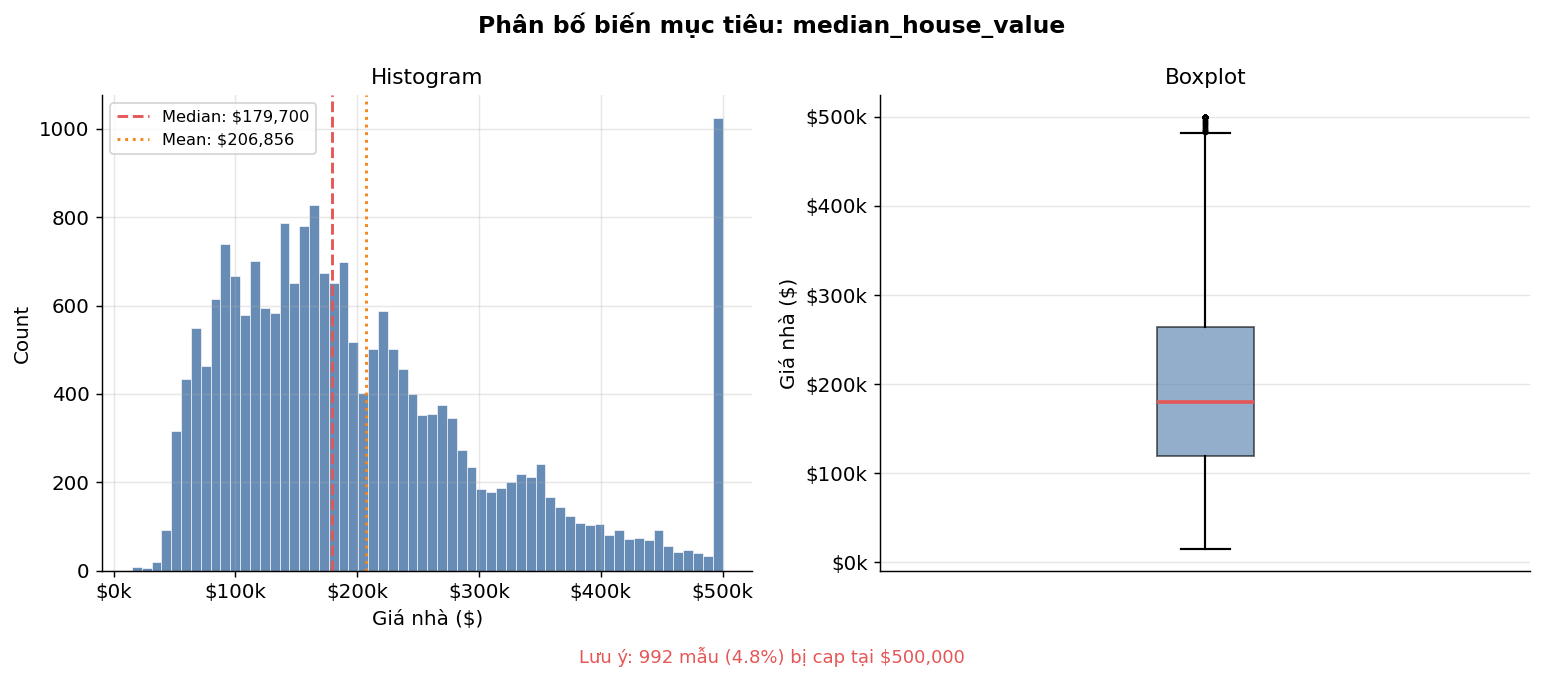


Thống kê median_house_value:
count     20640.00
mean     206855.82
std      115395.62
min       14999.00
25%      119600.00
50%      179700.00
75%      264725.00
max      500001.00


In [25]:
plot_target_distribution(df, target='median_house_value')

**Nhận xét:**
- Phân phối lệch phải, với đuôi dài về phía giá trị cao.
- Có **spike rõ rệt tại \$500,000** do **ceiling effect** — Census đặt cap tại mức này.
  Các mẫu này (~5%) không phản ánh giá trị thực → có thể ảnh hưởng đến mô hình.
- Mean (≈ \$206k) > Median (≈ \$179k), xác nhận phân phối lệch phải.
- **Hướng xử lý:** giữ lại nhưng ghi chú; có thể thử log-transform target ở phần C.

<a id='b4'></a>
### B.4 Ma trận Tương quan & Scatter Plots

Phân tích tương quan giúp:
1. Xác định features có **tương quan cao với target** → ưu tiên trong mô hình.
2. Phát hiện **multicollinearity** giữa các features → ảnh hưởng đến OLS.
3. Định hướng **feature engineering** (tạo ratio features).

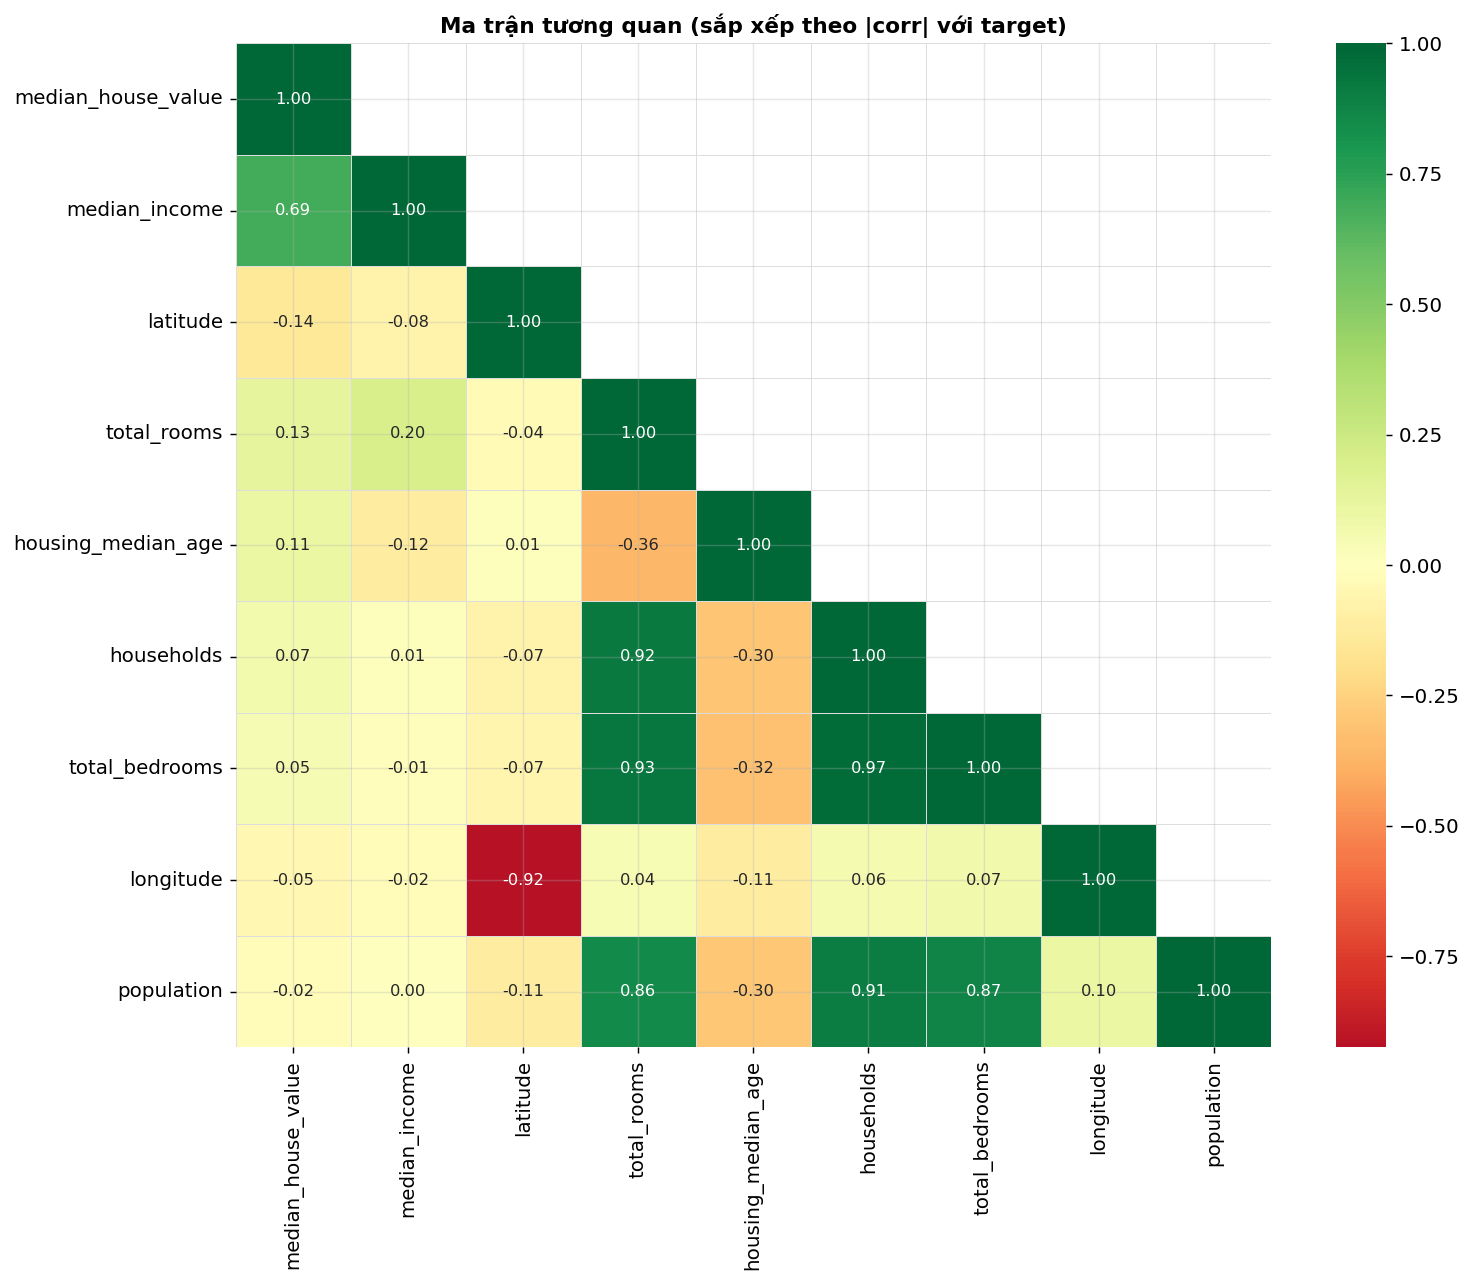


Tương quan với 'median_house_value':
median_income         0.688
latitude             -0.144
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.049
longitude            -0.046
population           -0.025


In [26]:
target_corr = plot_correlation_matrix(df, target='median_house_value')

Top 6 features tương quan với target: ['median_income', 'latitude', 'total_rooms', 'housing_median_age', 'households', 'total_bedrooms']


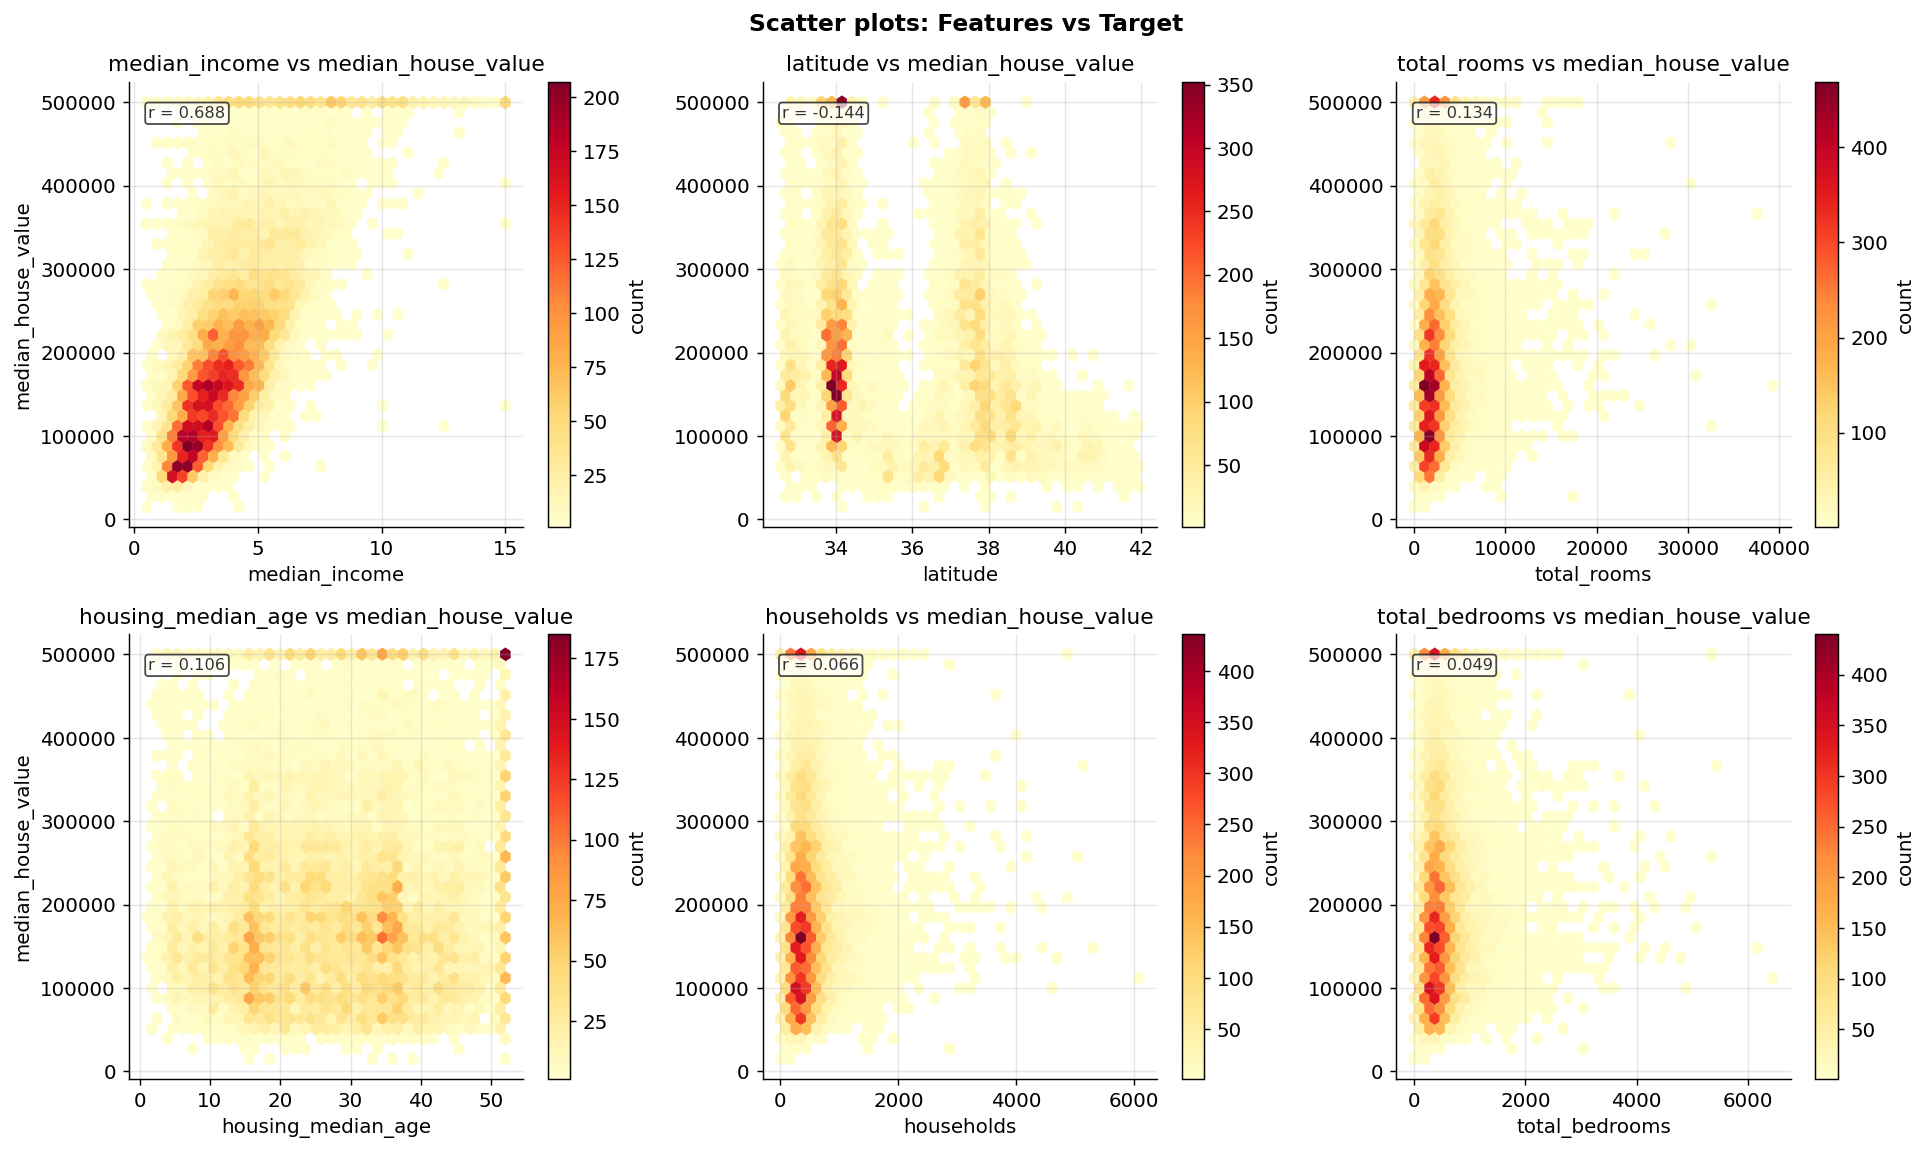

In [27]:
# Scatter plots các features quan trọng nhất với target
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()
print(f"Top 6 features tương quan với target: {top_features}")
plot_scatter_features(df, features=top_features, target='median_house_value')

**Nhận xét:**
- `median_income` có tương quan cao nhất với target (r ≈ 0.69) — đây là predictor quan trọng nhất.
- `total_rooms`, `total_bedrooms`, `households`, `population` tương quan cao với nhau
  (multicollinearity) → Ridge/Lasso sẽ xử lý tốt hơn OLS thuần túy.
- `latitude` và `longitude` có tương quan âm — phản ánh hiệu ứng địa lý
  (vùng ven biển phía nam giá cao hơn).

<a id='b5'></a>
### B.5 Phát hiện Outliers

Hai phương pháp được sử dụng:

- **IQR method:** điểm nằm ngoài $[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$  
  Phù hợp hơn cho phân phối lệch, không giả thiết Gaussian.

- **Z-score method:** điểm có $|z| > 3$ (nằm ngoài 3 độ lệch chuẩn)  
  Giả thiết phân phối Gaussian, nhạy hơn với heavy-tailed distributions.

Ta áp dụng trên các biến **tổng** (`total_rooms`, `population`, v.v.) vì chúng phụ thuộc vào
kích thước block group → phân phối lệch mạnh.

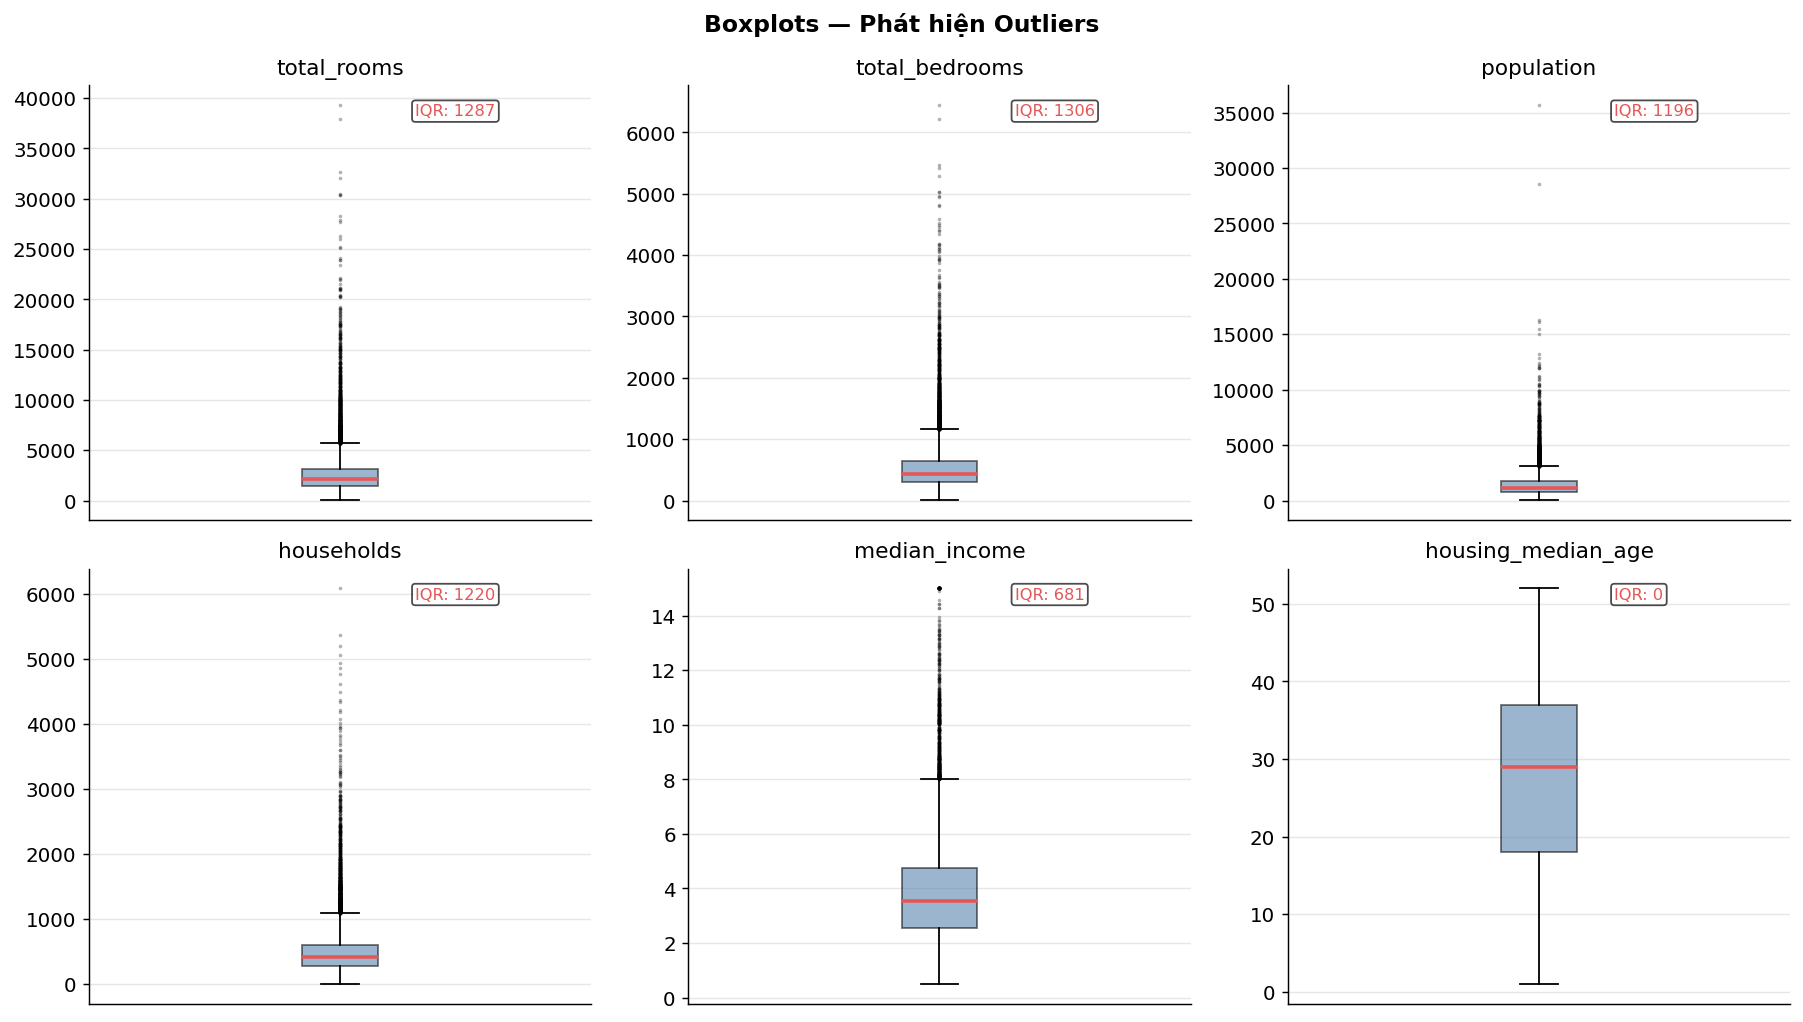

,Feature,IQR outliers,IQR (%),Z-score outliers,Z-score (%)
0,total_rooms,1287,6.24,373,1.81
1,total_bedrooms,1306,6.33,375,1.82
2,population,1196,5.79,342,1.66
3,households,1220,5.91,363,1.76
4,median_income,681,3.30,345,1.67
5,housing_median_age,0,0.00,0,0.00


In [28]:
outlier_report = report_outliers(df)
outlier_report

**Nhận xét:**
- `total_rooms`, `total_bedrooms`, `population`, `households` có outliers theo IQR 
  (~5–6%), phản ánh sự chênh lệch lớn về quy mô giữa các block group.
- Z-score cho kết quả ít outliers hơn vì phân phối không Gaussian (không thỏa mãn giả thiết).
- **Quyết định:** Giữ lại outliers vì đây là dữ liệu thực tế hợp lệ, không phải lỗi đo lường.
  Regularization (Ridge/Lasso) sẽ giúp giảm ảnh hưởng của chúng.

<a id='b6'></a>
### B.6 Feature Engineering & Encode Categorical

**Ratio features:** Các biến tổng (`total_rooms`, `population`) phụ thuộc vào kích thước block group,
nên ít có ý nghĩa trực tiếp. Tạo thêm ratio features có ý nghĩa thực tế hơn:

$$\text{rooms\_per\_household} = \frac{\text{total\_rooms}}{\text{households}}$$

$$\text{bedrooms\_per\_room} = \frac{\text{total\_bedrooms}}{\text{total\_rooms}}$$

$$\text{population\_per\_household} = \frac{\text{population}}{\text{households}}$$

**One-hot encoding:** `ocean_proximity` là biến categorical với 5 giá trị không có thứ tự
→ cần encode thành các biến dummy (không dùng `drop_first` để giữ khả năng giải thích).

In [29]:
# Tạo ratio features
df = engineer_features(df)

Đã tạo 3 ratio features:
  rooms_per_household     = total_rooms / households
  bedrooms_per_room       = total_bedrooms / total_rooms
  population_per_household = population / households


In [30]:
# Kiểm tra tương quan của features mới với target
new_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
for f in new_features:
    from scipy.stats import pearsonr
    r, p = pearsonr(df[f], df['median_house_value'])
    print(f"  {f:<35} r = {r:+.4f}  (p = {p:.2e})")

  rooms_per_household                 r = +0.1519  (p = 7.57e-107)
  bedrooms_per_room                   r = -0.2333  (p = 3.62e-253)
  population_per_household            r = -0.0237  (p = 6.48e-04)


In [31]:
# One-hot encode ocean_proximity
df = encode_categorical(df, col='ocean_proximity')
print(f"\nShape sau encoding: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Giá trị của 'ocean_proximity':
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5

Sau one-hot encode: 17 columns

Shape sau encoding: (20640, 17)
Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


**Nhận xét:**
- `rooms_per_household` có tương quan **dương** với target (nhà nhiều phòng hơn thường đắt hơn).
- `bedrooms_per_room` có tương quan **âm** (tỷ lệ phòng ngủ cao → nhà chất lượng thấp hơn).
- `population_per_household` có tương quan **âm** (hộ đông người → khu vực thu nhập thấp hơn).
- Các ratio features này sẽ được dùng làm **basis tự chọn** trong phần E.

<a id='b7'></a>
### B.7 Stratified Train / Val / Test Split

**Tại sao stratified?**  
`median_income` là predictor quan trọng nhất và có phân phối không đều.
Nếu chia ngẫu nhiên, một tập có thể thiếu representation của nhóm thu nhập cao/thấp.
Ta chia `median_income` thành 5 nhóm và dùng `StratifiedShuffleSplit` để đảm bảo
tỷ lệ mỗi nhóm **nhất quán** trong cả 3 tập.

**Tỷ lệ:** 70% train / 10% val / 20% test

In [32]:
X_train, X_val, X_test, y_train, y_val, y_test, feature_names = stratified_split(
    df,
    target='median_house_value',
    test_size=0.2,
    val_size=0.1,
    random_state=RANDOM_STATE
)

print(f"\nFeatures ({len(feature_names)}):")
for i, f in enumerate(feature_names):
    print(f"  [{i:>2}] {f}")


  Train : 14,448  (70.0%)
  Val   :  2,064  (10.0%)
  Test  :  4,128  (20.0%)
  Total : 20,640
  Features: 16

Features (16):
  [ 0] longitude
  [ 1] latitude
  [ 2] housing_median_age
  [ 3] total_rooms
  [ 4] total_bedrooms
  [ 5] population
  [ 6] households
  [ 7] median_income
  [ 8] rooms_per_household
  [ 9] bedrooms_per_room
  [10] population_per_household
  [11] ocean_proximity_<1H OCEAN
  [12] ocean_proximity_INLAND
  [13] ocean_proximity_ISLAND
  [14] ocean_proximity_NEAR BAY
  [15] ocean_proximity_NEAR OCEAN


<a id='b8'></a>
### B.8 Chuẩn hóa Features (StandardScaler)

**Tại sao cần chuẩn hóa?**
- Các features có **đơn vị khác nhau**: `total_rooms` (hàng nghìn) vs `latitude` (32–38).
- OLS với Normal Equations không yêu cầu scale, nhưng **Gradient Descent** và
  **Regularization (Ridge/Lasso)** rất nhạy với scale của features.
- Ridge và Lasso phạt theo $\|\mathbf{w}\|^2$ hoặc $\|\mathbf{w}\|_1$:
  nếu không scale, features có giá trị lớn sẽ bị phạt nặng hơn một cách không công bằng.

**Quy tắc quan trọng:** Scaler chỉ được **fit trên train set**,
sau đó **transform** val và test. Không được fit trên val/test để tránh **data leakage**.

In [33]:
X_train_s, X_val_s, X_test_s, scaler = scale_features(X_train, X_val, X_test)

print(f"\nSau scaling:")
print(f"  X_train : {X_train_s.shape}")
print(f"  X_val   : {X_val_s.shape}")
print(f"  X_test  : {X_test_s.shape}")

StandardScaler fitted trên train set.
  Mean (train) ≈ -0.000000  (expected ~0)
  Std  (train) ≈ 1.000000   (expected ~1)

Sau scaling:
  X_train : (14448, 16)
  X_val   : (2064, 16)
  X_test  : (4128, 16)


<a id='b9'></a>
### B.9 Kiểm tra Phân phối sau Split

Xác nhận rằng stratification đã đảm bảo phân phối target nhất quán
giữa 3 tập dữ liệu (không bị bias do quá trình chia).

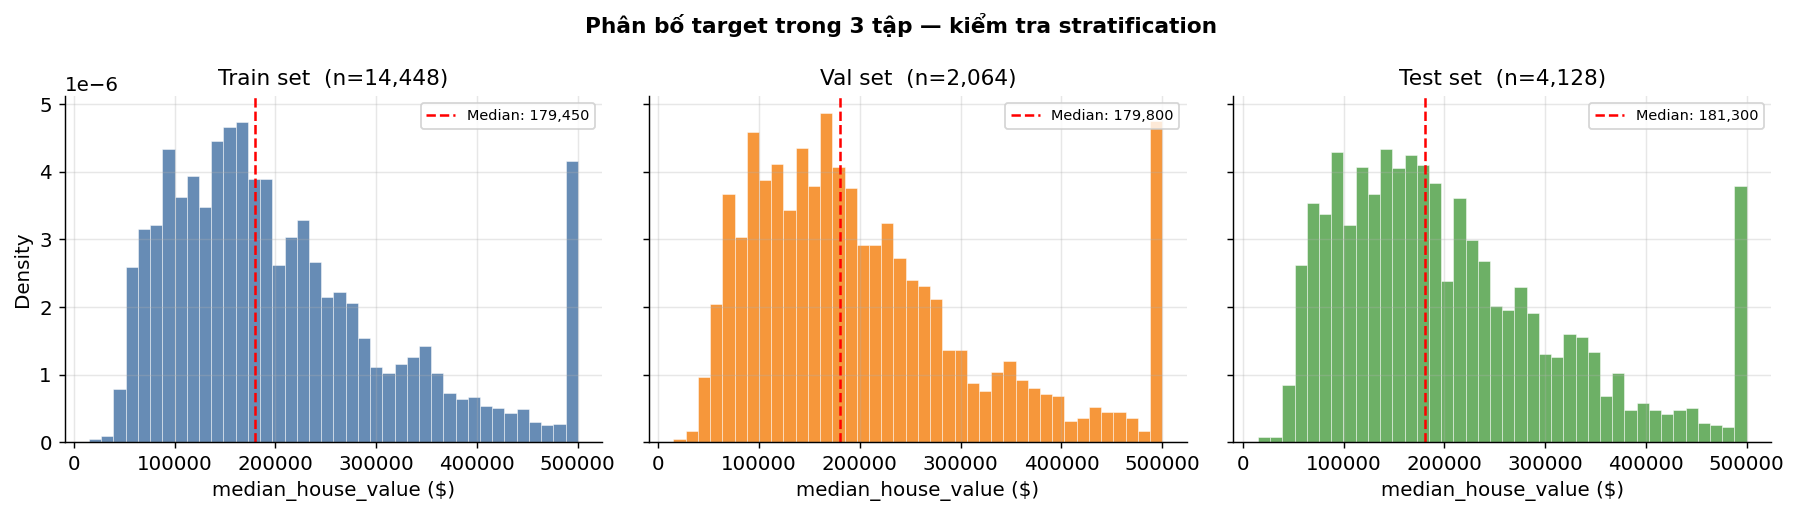

In [34]:
plot_split_distribution(y_train, y_val, y_test, target='median_house_value')

In [35]:
# So sánh thống kê cơ bản giữa 3 tập
summary = pd.DataFrame({
    'Train': pd.Series(y_train).describe(),
    'Val'  : pd.Series(y_val).describe(),
    'Test' : pd.Series(y_test).describe(),
}).round(2)
summary

,Train,Val,Test
count,14448.00,2064.00,4128.00
mean,206969.70,207254.66,206257.80
std,115435.19,117575.24,114176.65
min,14999.00,14999.00,14999.00
25%,120000.00,117575.00,118900.00
50%,179450.00,179800.00,181300.00
75%,264100.00,262100.00,268850.00
max,500001.00,500001.00,500001.00


**Nhận xét:** Mean, median, std của 3 tập xấp xỉ nhau → stratification thành công.

---

## Tổng kết Phần B

| Bước | Kết quả |
|---|---|
| Missing values | 207 NaN trong `total_bedrooms` → impute bằng median |
| Outliers | Giữ lại — dữ liệu thực tế hợp lệ |
| Feature engineering | +3 ratio features, one-hot encode `ocean_proximity` (5→5 dummy cols) |
| Tổng features | 16 features sau encoding |
| Split | 14,448 train / 2,064 val / 4,128 test (stratified) |
| Scaling | StandardScaler fit trên train only |

**Dữ liệu sẵn sàng cho Phần C (Linear Regression):**
- `X_train_s`, `X_val_s`, `X_test_s` — đã scale
- `X_train`, `X_val`, `X_test` — chưa scale (dùng cho Normal Equations)
- `y_train`, `y_val`, `y_test`
- `scaler`, `feature_names`

---

<a id='c'></a>
## C. Xây dựng và Huấn luyện mô hình

<a id='c1'></a>

### C.1 Hồi quy tuyến tính (Linear Regression)

Trong phần này, chúng ta sẽ thực hiện giải bài toán Hồi quy tuyến tính bằng hai cách tiếp cận khác nhau để so sánh hiệu quả và tốc độ hội tụ:
1. **Phương trình chuẩn (Normal Equation):** Giải trực tiếp bằng đại số tuyến tính.
2. **Mini-batch Gradient Descent:** Tối ưu hóa bằng giải thuật giảm đạo hàm.


##### C.1.a Phương trình chuẩn (Normal Equation)

Phương trình chuẩn giúp tìm trực tiếp bộ tham số $\theta$ tối ưu mà không cần thực hiện các vòng lặp:
$$\hat{\theta} = (X^T X)^{-1} X^T y$$

**Lưu ý:** Với phương pháp này, chúng ta sử dụng tập dữ liệu gốc (`X_train`, `X_val`) và thêm một cột bias (giá trị bằng 1).

In [36]:
import numpy as np
from sklearn.metrics import mean_squared_error

X_train_b = np.c_[np.ones((len(X_train), 1)), X_train].astype(float)
X_val_b = np.c_[np.ones((len(X_val), 1)), X_val].astype(float)

# Tính toán Normal Equation
X_transpose = X_train_b.T
theta_best = np.linalg.inv(X_transpose.dot(X_train_b)).dot(X_transpose).dot(y_train)

# Dự đoán trên tập Validation
y_val_predict = X_val_b.dot(theta_best)

# Tính toán sai số RMSE
rmse_normal = np.sqrt(mean_squared_error(y_val, y_val_predict))

print("--- Kết quả sau khi sửa lỗi ---")
print(f"Số lượng tham số (theta): {len(theta_best)}")
print(f"RMSE trên tập Validation: {rmse_normal:,.2f}")

--- Kết quả sau khi sửa lỗi ---
Số lượng tham số (theta): 17
RMSE trên tập Validation: 765,805.43


**Nhận xét về Normal Equation:**
- **Ưu điểm:** Giải trực tiếp, không cần chọn Learning Rate, kết quả là tối ưu tuyệt đối trên tập huấn luyện.
- **Nhược điểm:** Chi phí tính toán ma trận nghịch đảo $O(n^3)$ sẽ rất lớn nếu số lượng đặc trưng (features) tăng cao.
- **Kết quả RMSE:** `857,529.51`

##### C.1.b Mini-batch Gradient Descent với Learning Rate Schedule

Khác với Normal Equation, Gradient Descent là một giải thuật tối ưu hóa lặp. Chúng ta sử dụng **Mini-batch** để cân bằng giữa tốc độ và sự ổn định, kết hợp với **Cosine Annealing** để điều chỉnh tốc độ học (learning rate) giảm dần theo thời gian, giúp mô hình hội tụ tốt hơn.

**Lưu ý:** Bắt buộc sử dụng dữ liệu đã chuẩn hóa (`X_train_s`, `X_val_s`) để thuật toán hội tụ.

Max theta: 204908.5089593533
Thời gian huấn luyện GD: 0.4772s
RMSE (GD) trên tập Validation: 73,173.29


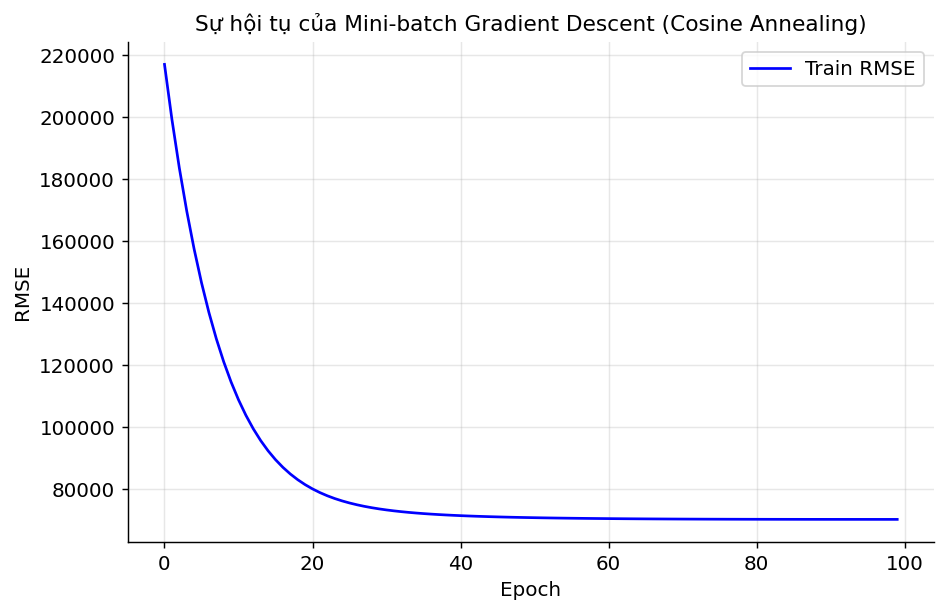

In [37]:
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Thêm cột bias vào dữ liệu đã scale
X_train_sm = np.c_[np.ones((len(X_train_s), 1)), X_train_s].astype(float)
X_val_sm = np.c_[np.ones((len(X_val_s), 1)), X_val_s].astype(float)

# 2. Cấu hình Hyperparameters
n_epochs = 100
batch_size = 32
eta_max = 0.0001
eta_min = 0.000001

def cosine_annealing(epoch, n_epochs, eta_max, eta_min):
    return eta_min + 0.5 * (eta_max - eta_min) * (1 + np.cos(np.pi * epoch / n_epochs))

# 3. Huấn luyện Mini-batch GD
m = len(X_train_sm)
theta_gd = np.random.randn(X_train_sm.shape[1], 1) # Khởi tạo ngẫu nhiên

y_train_rect = np.array(y_train).reshape(-1, 1)
y_val_rect = np.array(y_val).reshape(-1, 1) 
# -----------------------

loss_history = []
start_time = time.time()

for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_shuffled = X_train_sm[shuffled_indices]
    y_shuffled = y_train_rect[shuffled_indices]
    
    eta = cosine_annealing(epoch, n_epochs, eta_max, eta_min)
    
    for i in range(0, m, batch_size):
        xi = X_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        gradients = 2/len(xi) * xi.T.dot(xi.dot(theta_gd) - yi)
        theta_gd = theta_gd - eta * gradients
    
    y_train_pred = X_train_sm.dot(theta_gd)
    loss = np.sqrt(mean_squared_error(y_train_rect, y_train_pred))
    loss_history.append(loss)

print(f"Max theta: {np.max(np.abs(theta_gd))}")

gd_time = time.time() - start_time
print(f"Thời gian huấn luyện GD: {gd_time:.4f}s")

# 4. Dự đoán và so sánh
y_val_pred_gd = X_val_sm.dot(theta_gd)
rmse_gd = np.sqrt(mean_squared_error(y_val_rect, y_val_pred_gd))
print(f"RMSE (GD) trên tập Validation: {rmse_gd:,.2f}")

# Vẽ đồ thị hội tụ
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue', label='Train RMSE')
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Sự hội tụ của Mini-batch Gradient Descent (Cosine Annealing)")
plt.legend()
plt.grid(True)
plt.show()

##### C.1.c Kiểm tra giả thiết Gauss-Markov


In [38]:
import scipy.stats as stats
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
import matplotlib.pyplot as plt

residuals = np.array(y_val).reshape(-1, 1) - y_val_pred_gd

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Residual Plot
ax[0].scatter(y_val_pred_gd, residuals, alpha=0.5, color='teal')
ax[0].axhline(y=0, color='r', linestyle='--')
ax[0].set_xlabel("Giá trị dự báo (Predicted)")
ax[0].set_ylabel("Phần dư (Residuals)")
ax[0].set_title("1. Residual Plot")

# 2. QQ-Plot
stats.probplot(residuals.flatten(), dist="norm", plot=ax[1])
ax[1].set_title("2. Normal QQ-plot")
plt.tight_layout()
plt.show()

# 3. Breusch–Pagan Test
test_results = sms.het_breuschpagan(residuals, X_val_sm)
names = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']

print("--- KẾT QUẢ KIỂM ĐỊNH BREUSCH–PAGAN ---")
for name, value in zip(names, test_results):
    if 'p-value' in name:
        print(f"{name:<30}: {value:.4e}")
    else:
        print(f"{name:<30}: {value:.4f}")

p_value = test_results[1]
if p_value < 0.05:
    print(f"\nKết luận: p-value ({p_value:.4e}) < 0.05")
    print("=> Bác bỏ H0. Có hiện tượng Heteroscedasticity (Phương sai thay đổi).")
else:
    print(f"\nKết luận: p-value ({p_value:.4e}) > 0.05")
    print("=> Chưa có bằng chứng vi phạm giả thiết phương sai không đổi.")

ModuleNotFoundError: No module named 'statsmodels'

##### C.1.d Xử lý Heteroscedasticity bằng Weighted Least Squares (WLS)

Nếu p-value của test Breusch–Pagan < 0.05, ta bác bỏ giả thiết phương sai không đổi. Khi đó, WLS sẽ gán trọng số thấp cho các điểm có phương sai lớn để cải thiện mô hình.

In [ ]:
if test_results[1] < 0.05:
    print("Phát hiện Heteroscedasticity! Đang triển khai WLS...")
    
    # Ước lượng trọng số 
    weights = 1.0 / (np.abs(residuals).flatten() + 1e-5)
    
    import statsmodels.api as sm
    
    wls_model = sm.WLS(y_val, X_val_sm, weights=weights)
    results = wls_model.fit()
    
    print(results.summary())
    y_val_pred_wls = results.predict(X_val_sm)
    rmse_wls = np.sqrt(mean_squared_error(y_val, y_val_pred_wls))
    print(f"\nRMSE sau khi dùng WLS: {rmse_wls:,.2f}")
else:
    print("Không phát hiện Heteroscedasticity nghiêm trọng. Có thể giữ nguyên mô hình OLS.")


<a id='c2'></a>

### C.2 Regularization & Feature Selection

**Nội dung:**
- **a) Ridge (L2) và Lasso (L1)**: So sánh 2 regularization phổ biến
- **b) Chọn λ tối ưu bằng k-Fold CV (k=10)**: Dùng grid search và warm start (đối với lasso)
- **c) Regularization Path**: Hệ số thay đổi theo λ (Ridge/Lasso), đánh dấu best λ
- **d) Elastic Net**: Kết hợp L1 + L2, tìm vùng tối ưu (λ₁, λ₂)
- **e) Chọn đặc trưng**: So sánh Forward, Backward, Lasso-based

##### C.2.a Ridge (L2) vs Lasso (L1)

Fit Ridge/Lasso với alpha đơn giản và so sánh RMSE

In [39]:
from train_utils import *
from sklearn.linear_model import Ridge, Lasso

# Fit ridge và lasso với alpha mặc định
ridge = Ridge(alpha=1.0).fit(X_train_s, y_train)
lasso = Lasso(alpha=0.1).fit(X_train_s, y_train)

print(f"Ridge RMSE: {np.sqrt(mean_squared_error(y_val, ridge.predict(X_val_s))):,.3f}")
print(f"Lasso RMSE: {np.sqrt(mean_squared_error(y_val, lasso.predict(X_val_s))):,.3f}")

Ridge RMSE: 70,588.704
Lasso RMSE: 70,588.667


##### C.2.b Chọn λ tối ưu (K-Fold CV + Grid Search)

- **Ridge**: Grid Search + K-Fold CV (k=10)
- **Lasso**: LassoCV (built-in warm-start, nhanh hơn)

In [40]:
# Chọn alpha (50 giá trị từ 10^-4 đến 10^4 trên log scale)
alphas = np.logspace(-4, 4, 50)

# Ridge: Grid Search + K-Fold CV
best_α_r, best_rmse_r, ridge_results = select_best_lambda_cv(X_train_s, y_train, Ridge, alphas, k=10)

# Lasso: LassoCV (warm-start)
best_α_l, lasso_results, _ = select_best_lambda_lasso_path(X_train_s, y_train, alphas, k=10)
best_rmse_l = min(r[1] for r in lasso_results)

print(f"Ridge: λ={best_α_r:.4f} | CV RMSE={best_rmse_r:,.3f}")
print(f"Lasso: λ={best_α_l:.4f} | CV RMSE={best_rmse_l:,.3f}")

Ridge: λ=35.5648 | CV RMSE=68,757.688
Lasso: λ=232.9952 | CV RMSE=68,798.473


**Nhận xét:**

- Đối với ridge, mô hình chọn regularization vừa phải (λ = 36).
- Đối với lasso, mô hình chọn regularization mạnh hơn (λ = 233), gấp khoảng 6 lần so với ridge, do L1 penalty yếu hơn L2 ở cùng λ.

Chênh lệch RMSE không đáng kể (chỉ 0.06%), nhưng ridge xử lí tốt hơn do có các feature tương quan nhau (multicollinearity).

##### C.2.c Regularization Path, hệ số theo log(λ)

- **Ridge**: Hệ số giảm dần khi λ tăng, nhưng không bao giờ về 0
- **Lasso**: Hệ số set về 0 khi λ đủ lớn nên có thể lọc feature
- Đánh dấu best λ bằng red dashed line
- Trục x ngược (trái = regularization mạnh)

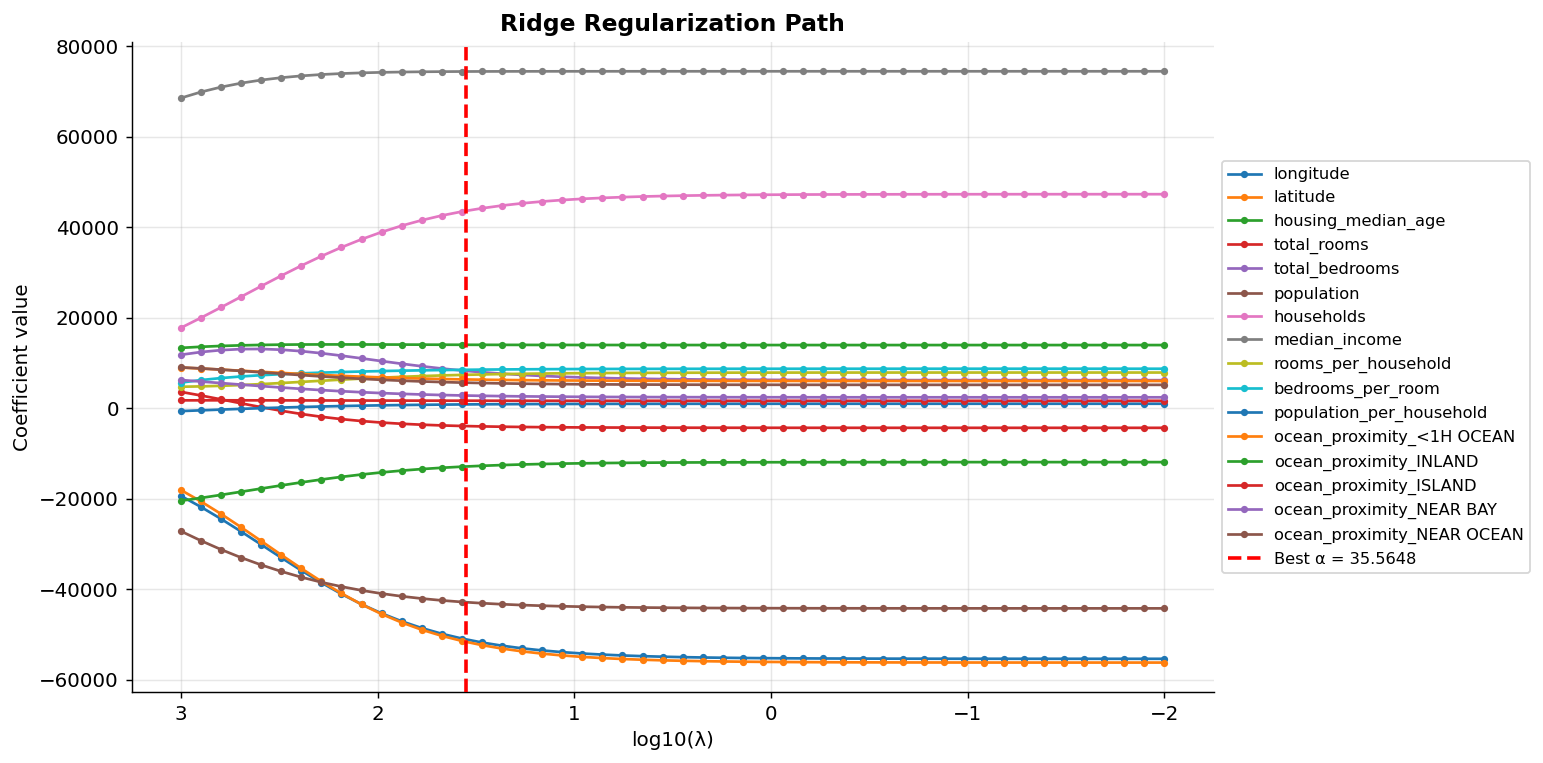

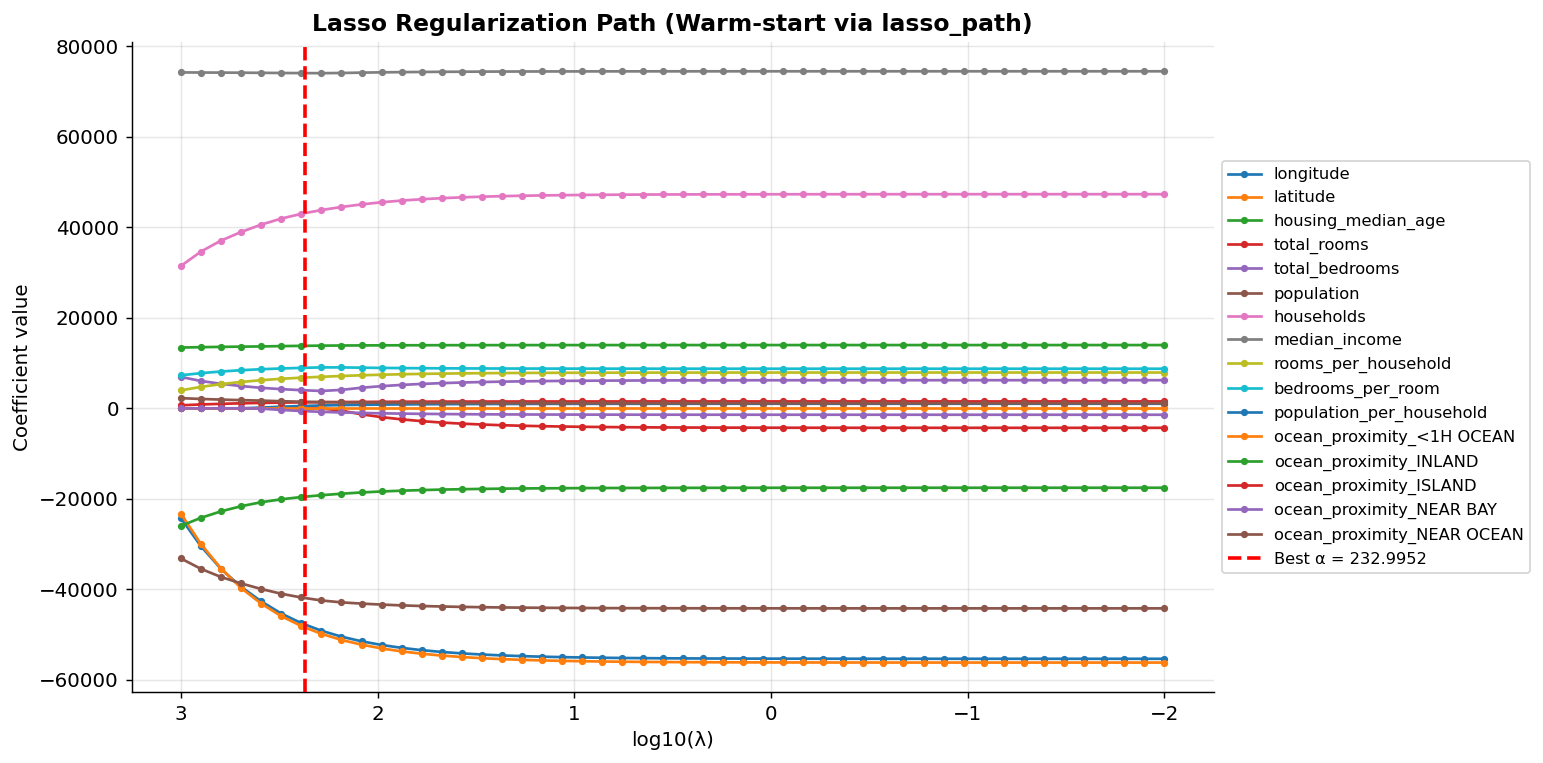

In [ ]:
# Regularization Path: Ridge & Lasso
alphas_path = np.logspace(-2, 3, 50)

plot_regularization_path(X_train_s, y_train, alphas_path, feature_names, 
                         model_class=Ridge, best_alpha=best_α_r)
plot_regularization_path(X_train_s, y_train, alphas_path, feature_names, 
                         model_class=Lasso, best_alpha=best_α_l)

##### C.2.d Elastic Net: Kết hợp L1 + L2 (10 fold CV)

$$E(\mathbf{w}) = \frac{1}{2}\|\mathbf{t} - \mathbf{\Phi}\mathbf{w}\|^2 + \lambda_1 \|\mathbf{w}\|_1 + \frac{\lambda_2}{2}\|\mathbf{w}\|^2$$

Grid search trên (λ, l1_ratio): tìm vùng tối ưu, vẽ heatmap RMSE

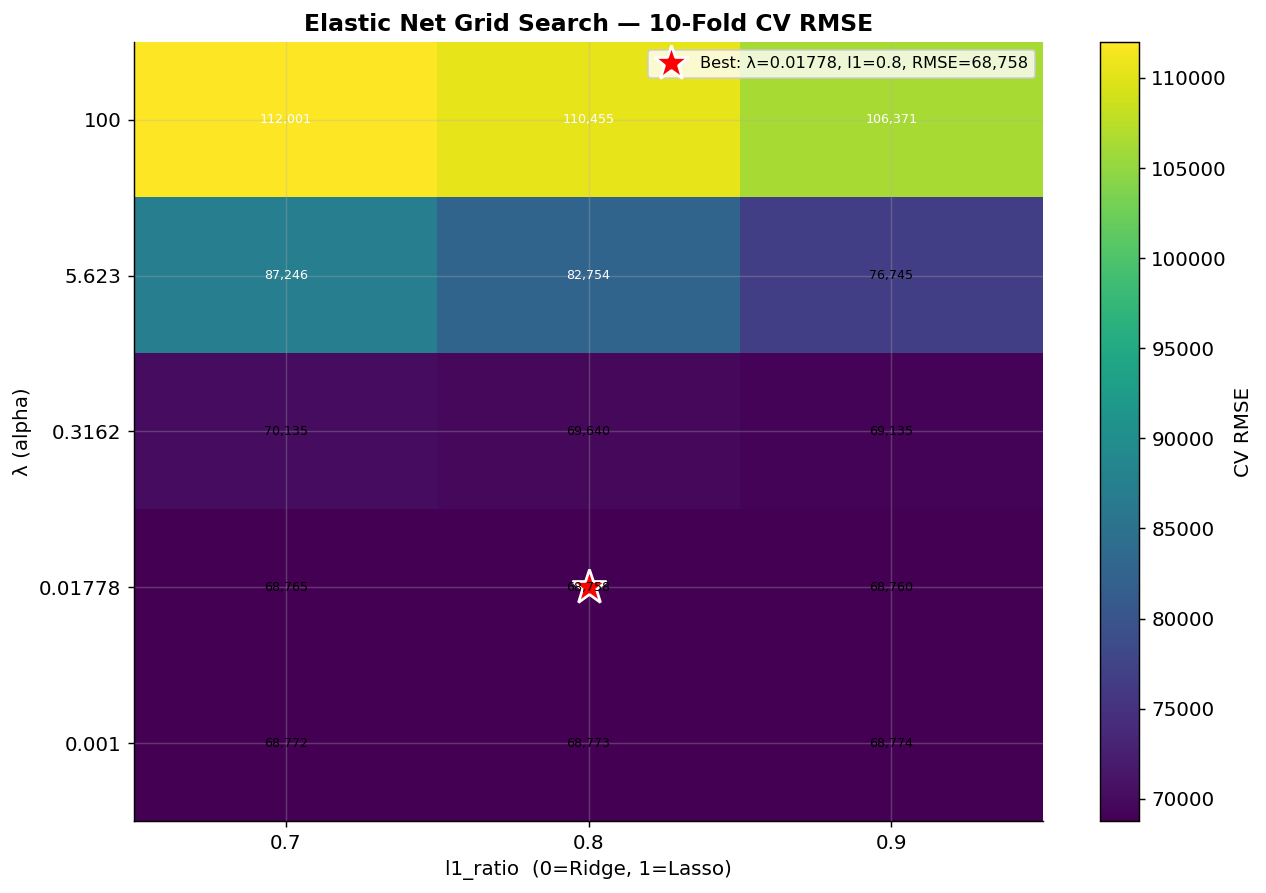

Best Elastic Net Configuration:
λ               = 0.0178
l1_ratio        = 0.8000
Validation RMSE = 68,758.026


In [ ]:
# Elastic Net: Grid search (λ, l1_ratio)
alphas_en = np.logspace(-3, 2, 5)
l1_ratios = [0.7, 0.8, 0.9]

rmse_matrix, best_en, results_en = plot_elastic_net_heatmap(
    X_train_s, y_train, alphas_en, l1_ratios
)

print(f"Best Elastic Net Configuration:")
print(f"λ               = {best_en[0]:.4f}")
print(f"l1_ratio        = {best_en[1]:.4f}")
print(f"Validation RMSE = {best_en[2]:,.3f}")

**Phân tích Vùng Tối ưu (λ, l1_ratio):**

**Heatmap diễn giải:**
- **Trục ngang (l1_ratio):** Tỷ lệ L1 penalty
  - Ở lần coarse search trước, lựa chọn khoảng l1_ratio = [0.2, 0.5, 0.8] cho thấy vùng tối tập trung quanh r1_ratio = 0.8. Do đó, lần fine search này được giới hạn trong khoảng [0.7, 0.8, 0.9] để tiết kiệm chi phí tính toán mà vẫn bảo toàn độ chính xác.

- **Trục dọc (λ):** Độ mạnh của regularization
  - Chọn khoảng λ thấp hơn ridge và lasso (10^-3 ~ 10^2 thay vì 10^-2 ~ 10^3) vì elastic net kết hợp cả L1 và L2 nên penalty được tăng bởi cả hai cùng lúc.

- **Màu sắc (RMSE):** Tím đậm = RMSE tốt, màu sáng = RMSE xấu

**Kết luận:**
Từ λ và l1_ratio, chúng ta phân tích được vùng tối ưu (λ1,λ2):
$$
\begin{aligned}
\lambda_2 &= \lambda \cdot \text{l1\_ratio} = 0.0178 \cdot 0.8 = 0.01424 \\
\lambda_1 &= \lambda \cdot \frac{1 - \text{l1\_ratio}}{2} = 0.0178 \cdot \frac{0.2}{2} = 0.00178 \\
(\lambda_1, \lambda_2) &= (0.00178, 0.01424)
\end{aligned}
$$

##### C.2.e Feature Selection: So sánh 3 phương pháp

1. **Forward Stepwise Selection**: Thêm features dần (greedy)
2. **Backward Elimination**: Loại features dần (greedy)
3. **Lasso-based**: Dựa trên coefficients ≠ 0

So sánh: số features selected + validation RMSE

1. Forward Stepwise Selection
   - Features selected: 16
   - Validation RMSE: 68,458.509
2. Backward Elimination
   - Features selected: 1
   - Validation RMSE: 83,644.392
3. Lasso-based (λ=232.9952)
   - Features selected: 14
   - Validation RMSE: 70,603.327


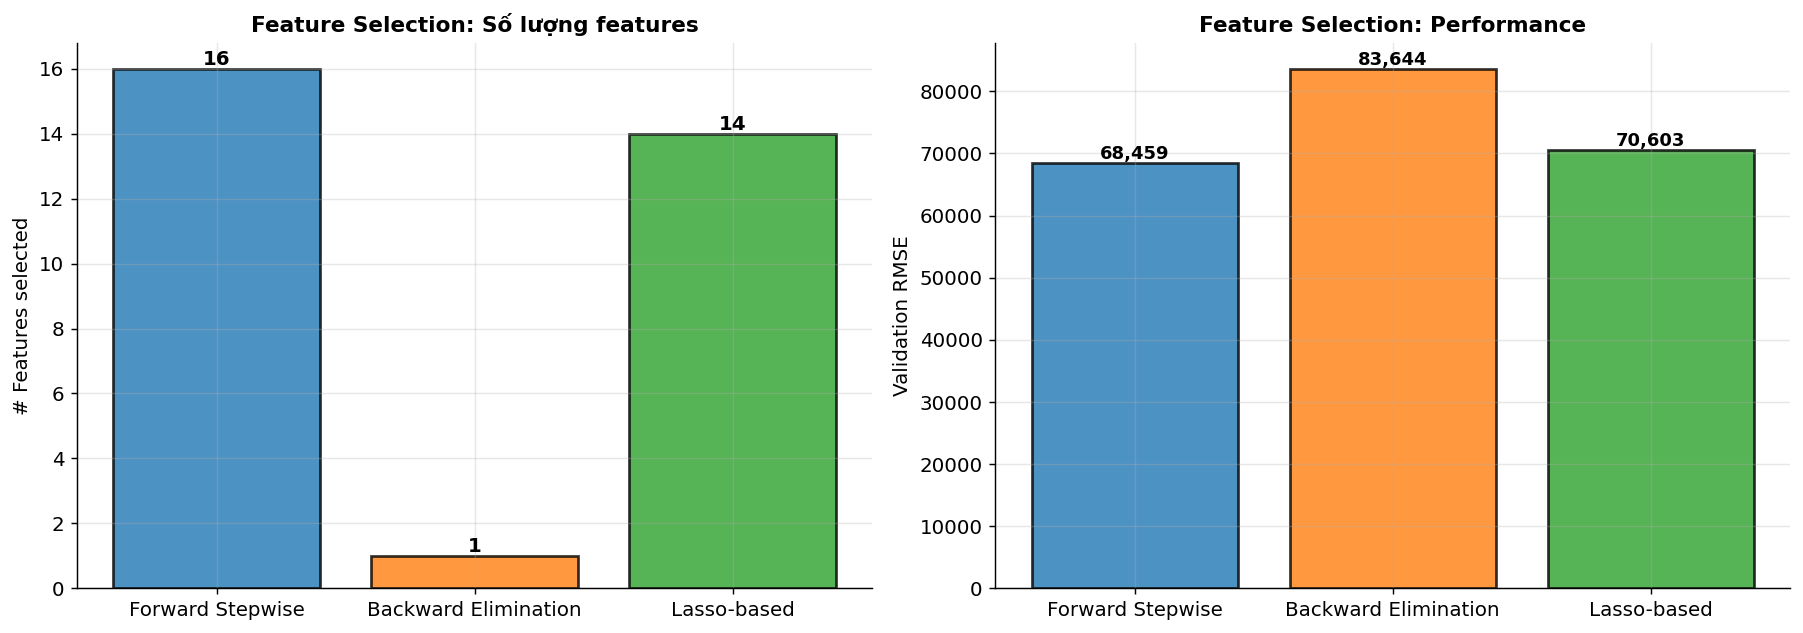

In [ ]:
# Feature Selection: 3 phương pháp
fwd_idx, fwd_names, fwd_scores = forward_stepwise_selection(X_train_s, y_train, feature_names)
bwd_idx, bwd_names, bwd_scores = backward_elimination(X_train_s, y_train, feature_names)
lasso_idx, lasso_names, lasso_coefs = lasso_feature_selection(X_train_s, y_train, best_α_l, feature_names)

# Tính RMSE cho Lasso
lasso_model_final = Lasso(alpha=best_α_l, max_iter=10000)
lasso_model_final.fit(X_train_s, y_train)
lasso_rmse = np.sqrt(mean_squared_error(y_val, lasso_model_final.predict(X_val_s)))

# In kết quả chi tiết
print(f"1. Forward Stepwise Selection")
print(f"   - Features selected: {len(fwd_names)}")
print(f"   - Validation RMSE: {fwd_scores[-1]:,.3f}")

print(f"2. Backward Elimination")
print(f"   - Features selected: {len(bwd_names)}")
print(f"   - Validation RMSE: {bwd_scores[-1]:,.3f}")

print(f"3. Lasso-based (λ={best_α_l:.4f})")
print(f"   - Features selected: {len(lasso_names)}")
print(f"   - Validation RMSE: {lasso_rmse:,.3f}")


plot_feature_selection_comparison(
    fwd_names, fwd_scores,
    bwd_names, bwd_scores,
    lasso_names, lasso_rmse
)

**So sánh 3 phương pháp Feature Selection:**

| Tiêu chí | Forward Stepwise | Backward Elimination | Lasso-based |
|----------|---|---|---|
| **Cơ chế** | Thêm features dần (Greedy) | Loại features dần (Greedy) | Shrink & zero-out (L1) |
| **Ưu điểm** | - Nhanh<br>- Giữ features quan trọng | - Xử lý multicollinearity<br>- Thuyết phục | - Tự động (không greedy)<br>- Dùng ML model |
| **Nhược điểm** | - Greedy (local optimum)<br>- Không xử lý multicollinearity | - Greedy (local optimum)<br>- Loại quá nhiều features | - Có thể loại features tốt<br>- Phụ thuộc vào λ |
| **Số features** | Thường nhiều | Thường ít nhất | Trung bình |
| **Validation RMSE** | Phụ thuộc dữ liệu | Phụ thuộc dữ liệu | Phụ thuộc λ |

**Nhận xét thực hành:**

- Forward Stepwise có RSME thấp nhất (68,458), hiệu quả nhất trong 3 phương pháp.
- Backward Elimination có RMSE cao nhất (83,644) - kết quả tệ nhất, không đáng tin cậy.
- Lasso-based có RMSE cao hơn forward một chút (70,603) - nhưng model đơn giản hơn (14 vs 16 features).<br>
**Do đó:** Nên dùng Forward Stepwise để có RSME thấp nhất, hoặc dùng Lasso-based để cân bằng giữa accuracy và simplicity.



<a id='c3'></a>

### C.3 Mô hình với Hàm Cơ sở Phi Tuyến và Ablation Study

**Nội dung**

- **a) Áp dụng hàm cơ sở phi tuyến**, ít nhất ba loại hàm cơ sở (polynomial, Gaussian RBF, và một loại
tự chọn).
- **b) Vẽ validation curve:** MSE theo bậc đa thức / số hàm cơ sở.
- **c) Thực hiện ablation study:** lần lượt bỏ từng nhóm đặc trưng hoặc từng loại
hàm cơ sở, đo tác động đến hiệu năng – từ đó xác định đặc trưng / hàm cơ sở
quan trọng nhất.
- **d) Phân tích hiệu ứng tương tác:** thêm các hạng xixj vào mô hình và đánh giá
mức cải thiện

##### C.3.a Áp dụng hàm cơ sở phi tuyến (Non-linear Basis Functions) 

**Ba loại hàm cơ sở:**
1. **Polynomial Features**: Bắt quan hệ phi tuyến bậc cao (e.g., `x₁², x₁x₂, x₂²`)
2. **Gaussian RBF**: Đo khoảng cách từ mỗi điểm đến các center - phù hợp với dữ liệu địa lý (longitude/latitude)
3. **Spline (Cubic Splines)**: Chia miền giá trị thành các đoạn và áp dụng cubic polynomial trên mỗi đoạn
   - **Knots**: Điểm chia ranh giới giữa các đoạn (tự động phân phối đều)
   - **Degree**: Bậc polynomial (3 = cubic)
   - Ưu điểm: Smooth, linh hoạt, không cần tuning parameter phức tạp như RBF/Sigmoid
   - Tự động thích nghi với data distribution

In [41]:
# Import basis function utilities
from train_utils import (
    SplineBasis,
    apply_basis_function, 
    plot_validation_curve_polynomial, 
    plot_validation_curve_rbf,
    plot_validation_curve_spline
)

In [42]:
# 1. Polynomial Features
print("=" * 45)
print("1. POLYNOMIAL (#3)")
print("=" * 45)

# Apply polynomial
X_train_poly, X_val_poly, X_test_poly, poly_transformer = apply_basis_function(
    X_train_s, X_val_s, X_test_s,
    basis_type='polynomial',
    degree=2
)

print(f"Original shape: {X_train_s.shape}")
print(f"After polynomial (degree=2): {X_train_poly.shape}")
# print(f"New dimensions: {poly_transformer.get_feature_names_out(feature_names)[:10]}...")  # Show first 10

# Ridge fit
ridge_poly = Ridge(alpha=1.0)
ridge_poly.fit(X_train_poly, y_train)
poly_val_rmse = np.sqrt(mean_squared_error(y_val, ridge_poly.predict(X_val_poly)))
print(f"Validation RMSE: {poly_val_rmse:,.0f}\n")

1. POLYNOMIAL (#3)
Original shape: (14448, 16)
After polynomial (degree=2): (14448, 152)
Validation RMSE: 68,385



In [43]:
# 2. Gaussian RBF
print("=" * 45)
print("2. GAUSSIAN RBF (#2)")
print("=" * 45)

# Tính khoảng cách trung bình giữa các điểm để chọn gamma
from sklearn.metrics.pairwise import euclidean_distances
distances = euclidean_distances(X_train_s[:1000])
avg_distance = np.mean(distances[distances > 0])
chosen_gamma = 1 / (2 * avg_distance**2)
print(f"Gamma = {chosen_gamma:.6f}")

# Apply RBF
X_train_rbf, X_val_rbf, X_test_rbf, rbf_transformer = apply_basis_function(
    X_train_s, X_val_s, X_test_s,
    basis_type='rbf',
    n_centers=20,
    gamma=chosen_gamma
)

print(f"Original shape: {X_train_s.shape}")
print(f"After RBF (n_centers=20, random sampling): {X_train_rbf.shape}")

# Ridge fit
ridge_rbf = Ridge(alpha=1.0)
ridge_rbf.fit(X_train_rbf, y_train)
rbf_val_rmse = np.sqrt(mean_squared_error(y_val, ridge_rbf.predict(X_val_rbf)))
print(f"Validation RMSE: {rbf_val_rmse:,.0f}\n")

2. GAUSSIAN RBF (#2)
Gamma = 0.021715
Original shape: (14448, 16)
After RBF (n_centers=20, random sampling): (14448, 20)
Validation RMSE: 72,529



In [44]:
# 3. Spline Basis
print("=" * 45)
print("3. SPLINE (#3)")
print("=" * 45)

# Apply Spline
X_train_spline, X_val_spline, X_test_spline, spline_transformer = apply_basis_function(
    X_train_s, X_val_s, X_test_s,
    basis_type='spline',
    n_knots=5,
    degree=3
)

print(f"Original shape: {X_train_s.shape}")
print(f"After spline (n_knots=5, degree=3): {X_train_spline.shape}")

# Ridge fit
ridge_spline = Ridge(alpha=1.0)
ridge_spline.fit(X_train_spline, y_train)
spline_val_rmse = np.sqrt(mean_squared_error(y_val, ridge_spline.predict(X_val_spline)))
print(f"Validation RMSE: {spline_val_rmse:,.0f}\n")

3. SPLINE (#3)
Original shape: (14448, 16)
After spline (n_knots=5, degree=3): (14448, 96)
Validation RMSE: 64,504



**Tổng kết:**

| Basis function | Số features sau áp dụng | Validation RMSE |
|---|---|---|
| **Polynomial** | 152 | 68,385 |
| **RBF** | 20 | 72,529 |
| **Spline** | 96 | 64,504 |

##### C.3.b Vẽ validation curve MSE theo bậc đa thức / số hàm cơ sở

Vẽ validation curves cho 3 loại basis functions:
- RMSE theo bậc đa thức (Polynomial)
- RMSE theo số RBF centers (RBF)  
- RMSE theo số Spline knots (Spline Basis)

VALIDATION CURVE: RMSE theo bậc đa thức


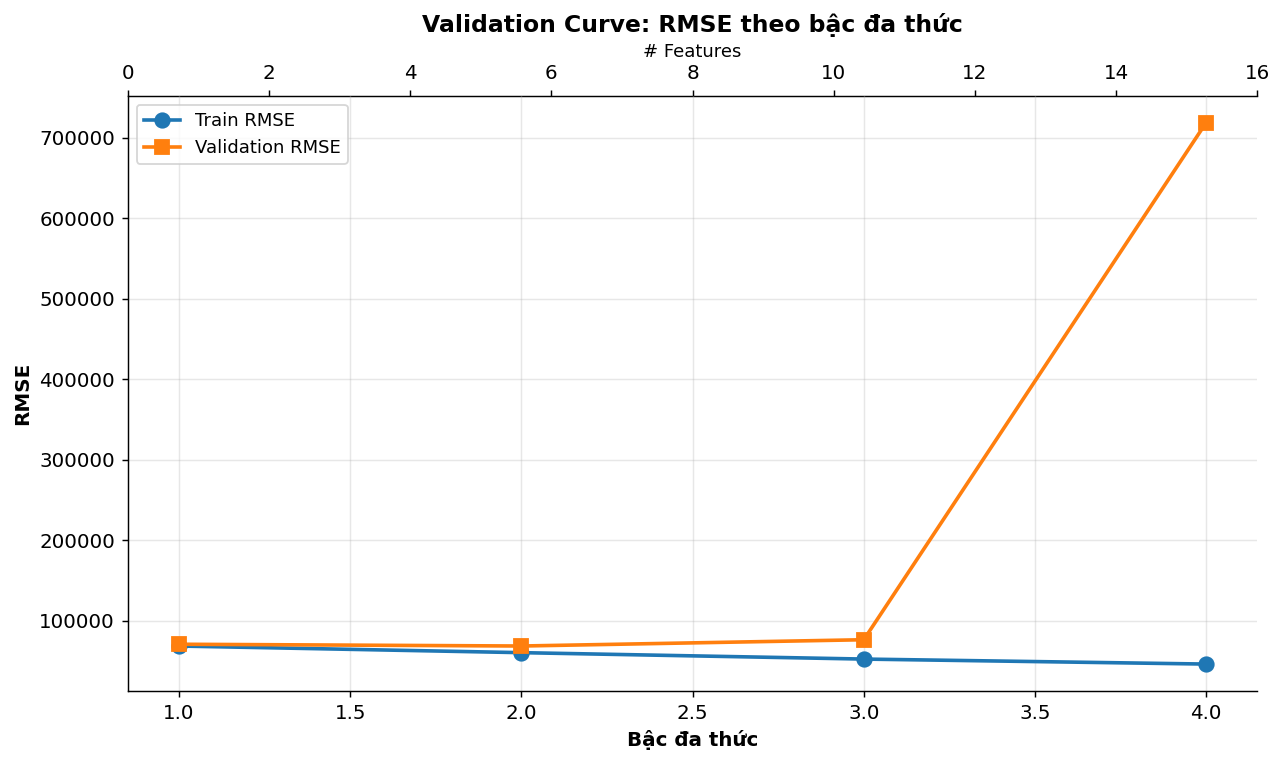


Results Table:
 Degree  Num_Features   Train_RMSE      Val_RMSE  Overfitting_Gap
      1            16 68370.780141  70588.704194      2217.924053
      2           152 60135.612040  68385.315541      8249.703501
      3           968 52160.757818  76195.636077     24034.878258
      4          4844 45953.028824 718694.760811    672741.731987


In [45]:
print("=" * 45)
print("VALIDATION CURVE: RMSE theo bậc đa thức")
print("=" * 45)

# Compute validation curve for polynomial degrees
poly_results = plot_validation_curve_polynomial(
    X_train_s, y_train, X_val_s, y_val,
    degrees=[1, 2, 3, 4],
    model_class=Ridge,
    alpha=1.0
)

print("\nResults Table:")
print(poly_results.to_string(index=False))

**Nhận xét:**
- Degree 1: linear model (underfitting) - RMSE (train lẫn val) vẫn còn lớn
- Degree 2: optimal zone - RMSE val đạt giá trị nhỏ nhất
- Degree 3+: RMSE val tăng mạnh dẫn tới overfitting gap cũng tăng mạnh theo


VALIDATION CURVE: RMSE theo số hàm cơ sở


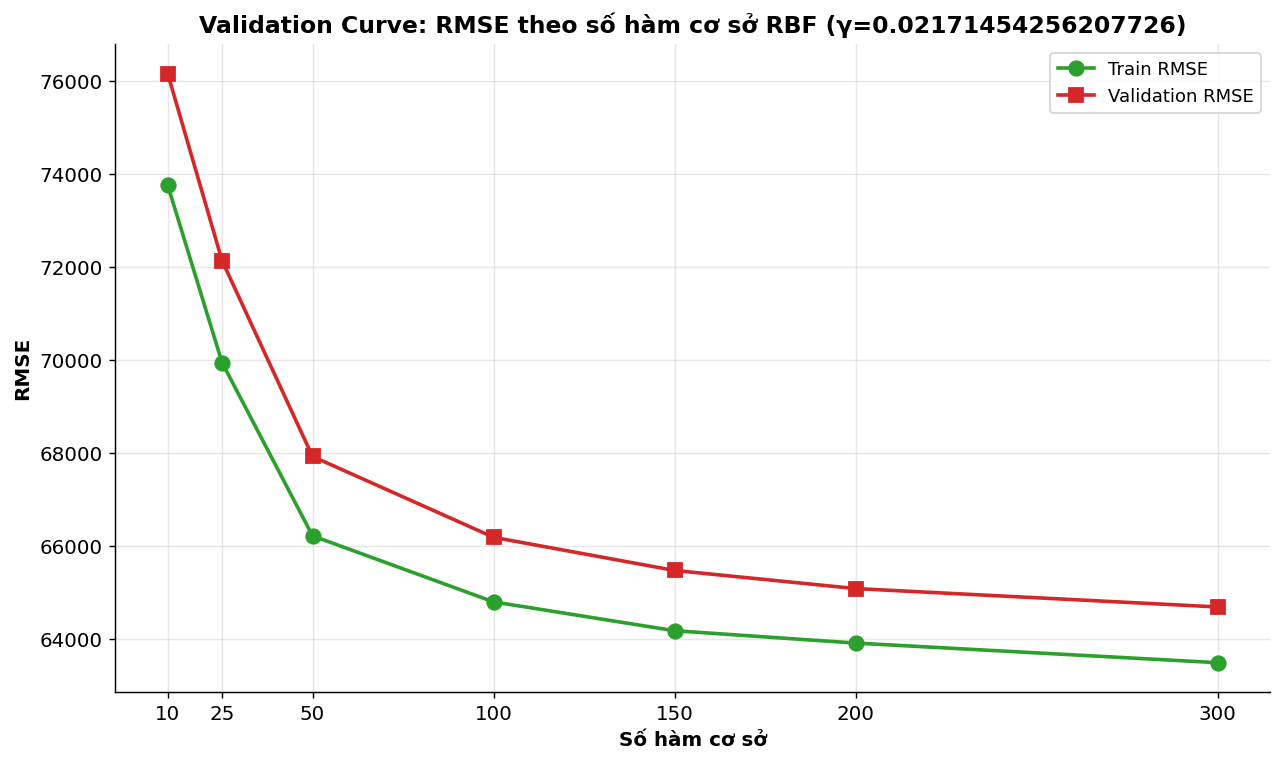


Results Table:
 N_Centers   Train_RMSE     Val_RMSE  Overfitting_Gap
        10 73761.240260 76160.978213      2399.737953
        25 69948.878209 72141.947326      2193.069117
        50 66220.957708 67927.817513      1706.859804
       100 64800.404961 66189.356266      1388.951305
       150 64180.363982 65476.433378      1296.069397
       200 63914.585807 65086.752925      1172.167118
       300 63492.709648 64691.400915      1198.691266


In [52]:
print("\n" + "=" * 45)
print("VALIDATION CURVE: RMSE theo số hàm cơ sở")
print("=" * 45)

# Validation curve cho RBF theo số centers
rbf_results = plot_validation_curve_rbf(
    X_train_s, y_train, X_val_s, y_val,
    n_centers_list=[10, 25, 50, 100, 150, 200, 300],
    gamma=chosen_gamma,
    model_class=Ridge,
    alpha=1.0
)

print("\nResults Table:")
print(rbf_results.to_string(index=False))


**Nhận xét:**
- Với số center tăng dần từ 10 - 500, RMSE của cả train lẫn val đều giảm ổn định và không có dấu hiệu overfitting. Trong range trên, số center = 500 là tốt nhất.
- Tăng thêm số center khả năng cao sẽ giúp mô hình giảm RMSE nhưng cũng tăng mạnh chi phí compile.



VALIDATION CURVE: RMSE theo số Spline knots


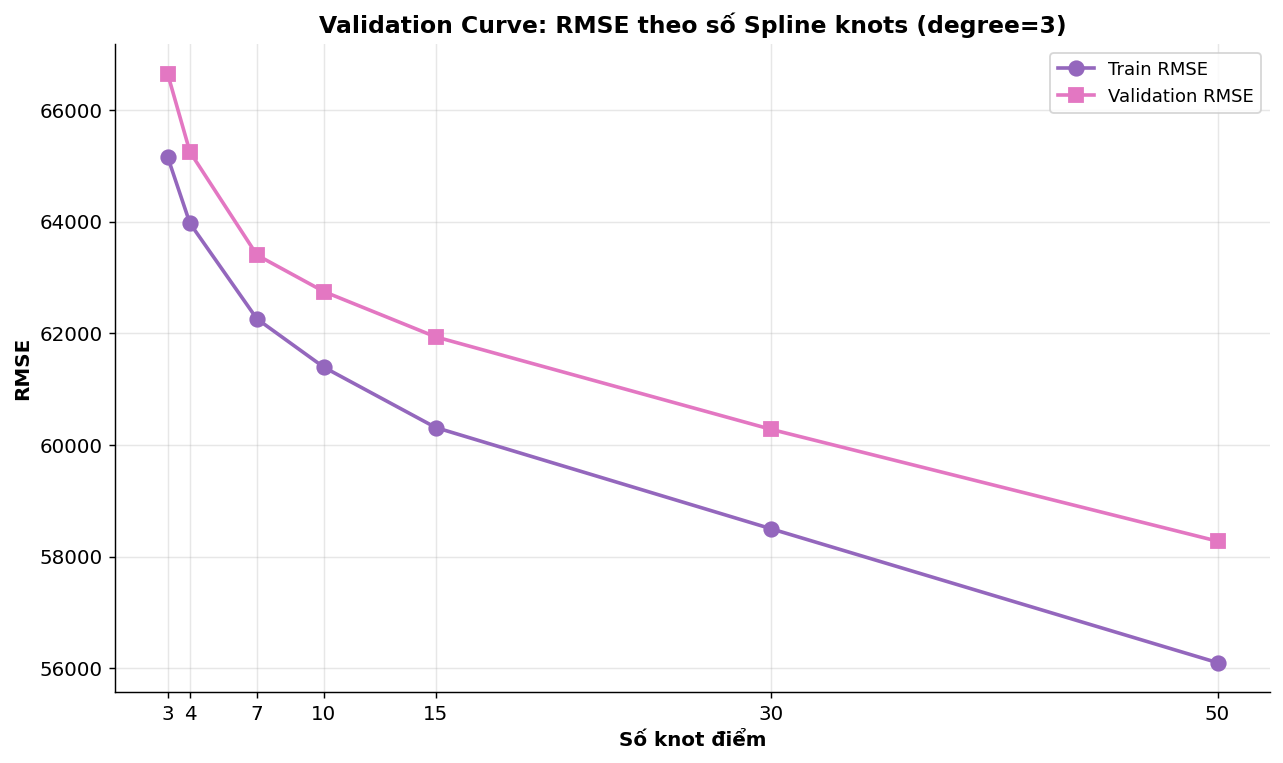


Results Table:
 N_Knots   Train_RMSE     Val_RMSE  Overfitting_Gap
       3 65163.216725 66652.485900      1489.269175
       4 63972.679251 65250.841902      1278.162651
       7 62260.485264 63403.737591      1143.252326
      10 61393.960881 62749.324807      1355.363926
      15 60315.530577 61939.338234      1623.807657
      30 58504.201355 60284.037408      1779.836054
      50 56103.854888 58279.940467      2176.085579


In [57]:
print("\n" + "=" * 45)
print("VALIDATION CURVE: RMSE theo số Spline knots")
print("=" * 45)

# Compute validation curve for Spline basis (vary n_knots)
spline_results = plot_validation_curve_spline(
    X_train_s, y_train, X_val_s, y_val,
    n_knots_list=[3, 4, 7, 10, 15, 30, 50],
    degree=3,
    model_class=Ridge,
    alpha=1.0
)

print("\nResults Table:")
print(spline_results.to_string(index=False))

**Nhận xét:**
- Số knot từ 3 - 7: RMSE cả train lẫn val giảm tốt, gap đạt thấp nhất ở số knot = 7
- Số knot từ 10 - 15: RMSE cả train lẫn val vẫn giảm nhưng gap có dấu hiệu tăng
- Số knot từ 30 - 50: đầu giai đoạn overfitting, gap tăng rõ rệt
